In [11]:
# ============================================
# IPL Win Probability Predictor
# Day 7 — SHAP Explainability
# Addition 2 — Making the Model Explainable
# ============================================
# GOAL: Use SHAP values to explain WHY our model
# makes each prediction, globally and per-match

# Install shap 
!pip install shap

In [12]:
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

print("SHAP version:", shap.__version__)
print("✅ All libraries imported")

SHAP version: 0.52.0
✅ All libraries imported


In [13]:
# Reload data
model_df = pd.read_csv("../data/model_ready_data.csv")

# Encode teams
model_df_encoded = pd.get_dummies(model_df, columns=['batting_team', 'bowling_team'])

# Store match IDs for group splitting
match_ids = model_df_encoded['match_id'].values

# Features and target
X = model_df_encoded.drop(columns=['match_id', 'batting_team_won'])
y = model_df_encoded['batting_team_won']

# Recreate exact same train/test split as Phase 6
from sklearn.model_selection import train_test_split

unique_matches = model_df_encoded['match_id'].unique()
train_match_ids, test_match_ids = train_test_split(
    unique_matches, test_size=0.2, random_state=42
)

train_data = model_df_encoded[model_df_encoded['match_id'].isin(train_match_ids)]
test_data  = model_df_encoded[model_df_encoded['match_id'].isin(test_match_ids)]

X_train = train_data.drop(columns=['match_id', 'batting_team_won'])
y_train = train_data['batting_team_won']
X_test  = test_data.drop(columns=['match_id', 'batting_team_won'])
y_test  = test_data['batting_team_won']

# Retrain Xgboost (same settings)
xgb_model=xgb.XGBClassifier(n_estimators=100,random_sate=42,eval_metric='logloss',verbosity=0)
xgb_model.fit(X_train,y_train)

print("✅ Data loaded, model trained")
print(f"Training rows: {X_train.shape[0]}")
print(f"Testing rows:  {X_test.shape[0]}")

✅ Data loaded, model trained
Training rows: 66968
Testing rows:  16512


In [14]:
# Create SHAP explainer for our Xgboost
explainer=shap.TreeExplainer(xgb_model)

print("✅ SHAP TreeExplainer created")
base_value = float(explainer.expected_value[0])

print(f"Expected base value: {base_value:.4f}")

prob = 1/(1+np.exp(-base_value))
print(f"Base probability: {prob*100:.2f}%")

✅ SHAP TreeExplainer created
Expected base value: 0.0090
Base probability: 50.23%


In [15]:
# Calculate SHAP values
sample_size = 1000
X_test_sample = X_test.sample(n=sample_size, random_state=42)
shap_values = explainer.shap_values(X_test_sample)

# Handle both RF format (list of arrays) and XGBoost format (single array)
if isinstance(shap_values, list):
    # Random Forest style — list of [class_0_values, class_1_values]
    shap_values_win = shap_values[1]
    print("Format: list (Random Forest style)")
else:
    # XGBoost style — single array already for positive class
    shap_values_win = shap_values
    print("Format: single array (XGBoost style)")

print(f"✅ SHAP values calculated")
print(f"Shape: {shap_values_win.shape}")

Format: single array (XGBoost style)
✅ SHAP values calculated
Shape: (1000, 32)


Selected prediction:
Win probability: 100.0%

Match situation:
  current_score: 162.00
  wicket_fallen: 0.00
  balls_remaining: 36.00
  runs_remaining: 22.00
  current_run_rate: 11.57
  required_run_rate: 3.67


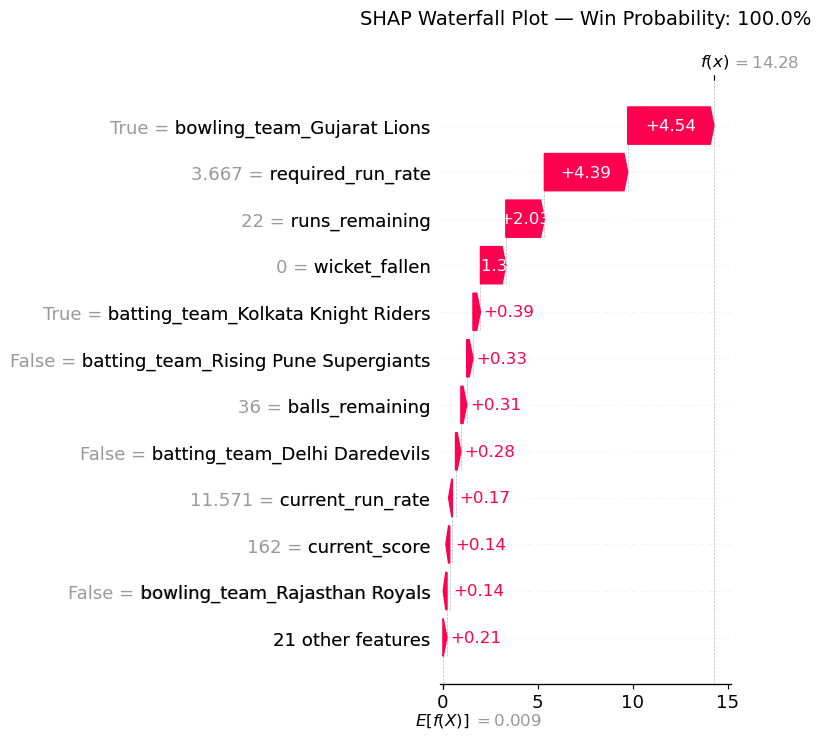

✅ Waterfall plot saved


In [16]:
# Pick one interesting test prediction to explain
# Let's find a match where model predicted high win probability
win_probs = xgb_model.predict_proba(X_test_sample)[:, 1]
high_win_idx = np.argmax(win_probs)  # row with highest win probability

print(f"Selected prediction:")
print(f"Win probability: {win_probs[high_win_idx]*100:.1f}%")
print(f"\nMatch situation:")
situation = X_test_sample.iloc[high_win_idx]

# Show only the core cricket features (not team columns)
core_features = ['current_score', 'wicket_fallen', 'balls_remaining', 
                 'runs_remaining', 'current_run_rate', 'required_run_rate']
for feat in core_features:
    print(f"  {feat}: {situation[feat]:.2f}")

# Create waterfall plot
plt.figure(figsize=(12, 6))
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values_win[high_win_idx],
        base_values=base_value,
        data=X_test_sample.iloc[high_win_idx],
        feature_names=X_test_sample.columns.tolist()
    ),
    max_display=12,
    show=False
)
plt.title(f'SHAP Waterfall Plot — Win Probability: {win_probs[high_win_idx]*100:.1f}%', 
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../output/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Waterfall plot saved")


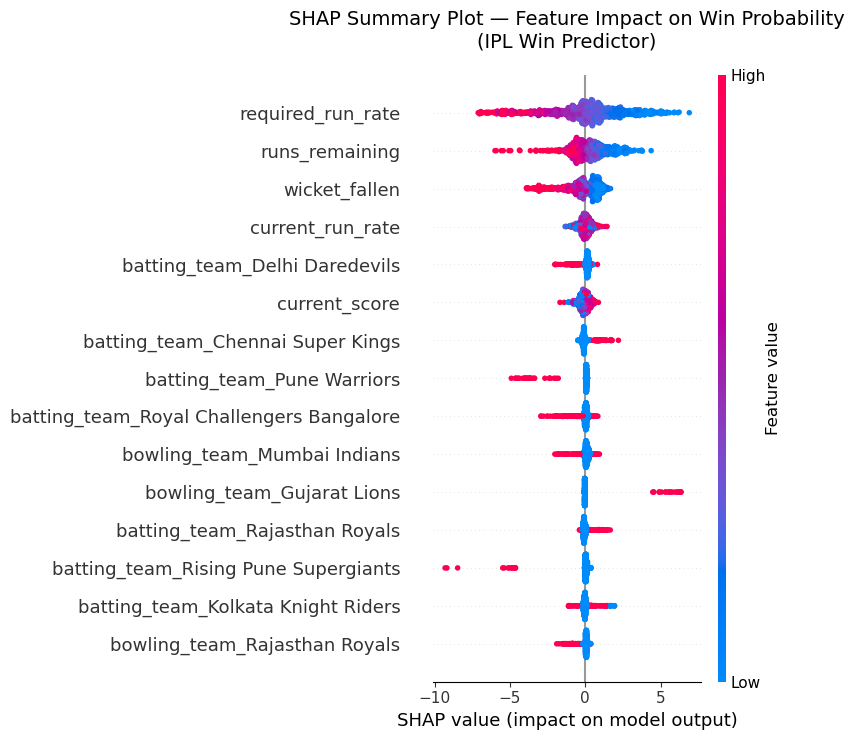

✅ Beeswarm summary plot saved


In [17]:
# Beeswarm plot - shows SHAP values across ALL 1000 sample predictions
plt.figure(figsize=(12, 8))

shap.summary_plot(
    shap_values_win,
    X_test_sample,
    max_display=15,
    show=False
)

plt.title('SHAP Summary Plot — Feature Impact on Win Probability\n(IPL Win Predictor)',
          fontsize=14, pad=20)
plt.tight_layout()
plt.savefig('../output/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Beeswarm summary plot saved")

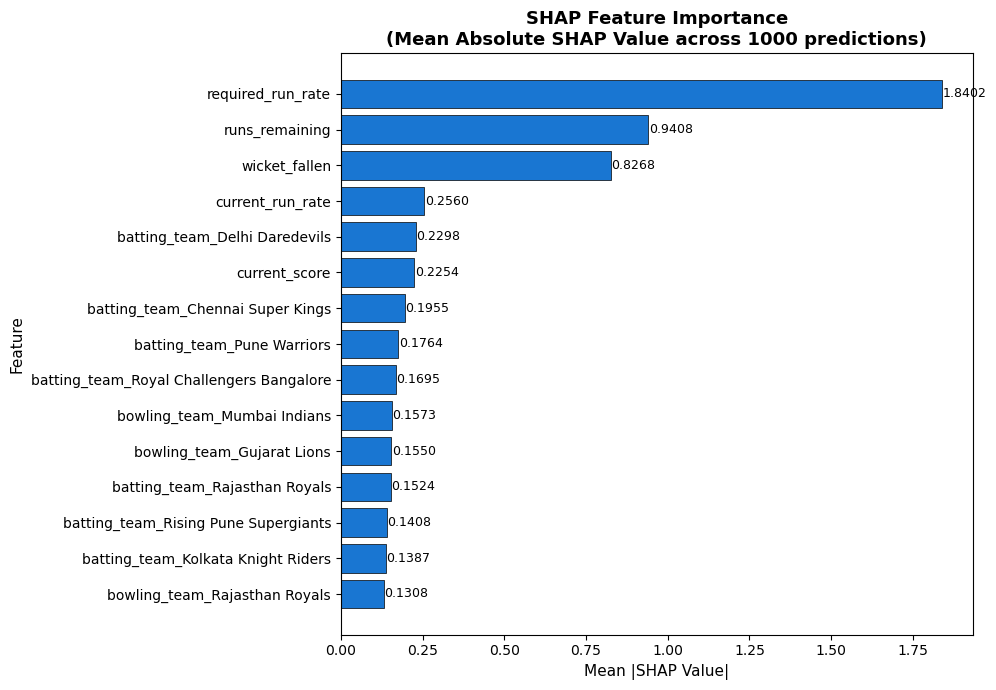

✅ Feature importance plot saved


In [18]:
# Calculate mean absolute SHAP value per feature
mean_shap = np.abs(shap_values_win).mean(axis=0)
shap_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'mean_abs_shap': mean_shap
}).sort_values('mean_abs_shap', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

bars = ax.barh(
    shap_importance['feature'][::-1],
    shap_importance['mean_abs_shap'][::-1],
    color='#1976D2',
    edgecolor='black',
    linewidth=0.5
)

# Add value labels
for bar, val in zip(bars, shap_importance['mean_abs_shap'][::-1]):
    ax.text(
        bar.get_width() + 0.001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center', fontsize=9
    )

ax.set_title('SHAP Feature Importance\n(Mean Absolute SHAP Value across 1000 predictions)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
plt.tight_layout()
plt.savefig('../output/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance plot saved")

In [19]:
# Built-in Random Forest importance (what we used in Phase 6)
builtin_importance = pd.DataFrame({
    'feature': X_train.columns,
    'builtin_importance': xgb_model.feature_importances_
}).sort_values('builtin_importance', ascending=False).head(10)

# SHAP importance (top 10)
shap_importance_top10 = shap_importance.head(10).reset_index(drop=True)

print("TOP 10 FEATURES — TWO METHODS COMPARED")
print("=" * 60)
print(f"{'Rank':<6} {'Built-in Importance':<35} {'SHAP Importance':<30}")
print("-" * 60)

for i in range(10):
    builtin_feat = builtin_importance.iloc[i]['feature']
    shap_feat = shap_importance_top10.iloc[i]['feature']
    match = "✅" if builtin_feat == shap_feat else "❌"
    print(f"{i+1:<6} {builtin_feat:<35} {shap_feat:<30} {match}")

print("=" * 60)
print("\n✅ = same feature at same rank in both methods")
print("❌ = methods disagree on this rank position")

TOP 10 FEATURES — TWO METHODS COMPARED
Rank   Built-in Importance                 SHAP Importance               
------------------------------------------------------------
1      required_run_rate                   required_run_rate              ✅
2      batting_team_Pune Warriors          runs_remaining                 ❌
3      batting_team_Rising Pune Supergiants wicket_fallen                  ❌
4      batting_team_Deccan Chargers        current_run_rate               ❌
5      bowling_team_Gujarat Lions          batting_team_Delhi Daredevils  ❌
6      bowling_team_Mumbai Indians         current_score                  ❌
7      batting_team_Royal Challengers Bangalore batting_team_Chennai Super Kings ❌
8      batting_team_Gujarat Lions          batting_team_Pune Warriors     ❌
9      batting_team_Kolkata Knight Riders  batting_team_Royal Challengers Bangalore ❌
10     bowling_team_Rajasthan Royals       bowling_team_Mumbai Indians    ❌

✅ = same feature at same rank in both methods
❌

In [20]:
# Find the most impactful feature according to SHAP
top_feature = shap_importance.iloc[0]['feature']
top_shap_val = shap_importance.iloc[0]['mean_abs_shap']

print(f"Most impactful feature: {top_feature}")
print(f"Average SHAP contribution: {top_shap_val:.4f}")
print(f"\nCricket interpretation:")

if 'required_run_rate' in top_feature:
    print("""
Required Run Rate is the #1 predictor of match outcomes.
This makes deep cricket sense:
- RRR < 7: Team is comfortably ahead → high win probability
- RRR 7-9: Match is evenly contested → uncertain  
- RRR > 10: Team is under severe pressure → low win probability
- RRR > 15: Match is essentially over → very low win probability

The model has independently learned what every cricket 
commentator knows intuitively — required run rate is the 
single most revealing statistic of a team's match situation.
    """)
elif 'wicket' in top_feature:
    print("""
Wickets fallen is the #1 predictor of match outcomes.
This reflects the core cricket principle:
- Wickets in hand = batting resources remaining
- Losing early wickets dramatically reduces win probability
- A team at 80/1 vs 80/5 are in completely different situations
    """)
else:
    print(f"""
{top_feature} emerged as the strongest predictor.
Analyze how this feature relates to cricket match dynamics
and write your own interpretation for the GitHub README.
    """)

Most impactful feature: required_run_rate
Average SHAP contribution: 1.8402

Cricket interpretation:

Required Run Rate is the #1 predictor of match outcomes.
This makes deep cricket sense:
- RRR < 7: Team is comfortably ahead → high win probability
- RRR 7-9: Match is evenly contested → uncertain  
- RRR > 10: Team is under severe pressure → low win probability
- RRR > 15: Match is essentially over → very low win probability

The model has independently learned what every cricket 
commentator knows intuitively — required run rate is the 
single most revealing statistic of a team's match situation.
    
